<a href="https://colab.research.google.com/github/CharlieHubbard7/NFLResearch/blob/main/(6_9_26)_NFL_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NFL Research

This notebook contains my work for the fourth week of work with Professor Ron Yurko at Carnegie Mellon's Sports Analytics Center. I use Madden ratings to explore what stats teams value in players of different position groups

##Data Wrangling

### Installs and Imports


In [1]:
!pip install nflreadpy #This is from the NFLverse package: https://github.com/nflverse/nflreadpy
!pip install rapidfuzz -q #This helps match the NFL roster with the madden data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 29.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import string
import re
from scipy import stats
from scipy.stats import zscore
import math
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import nflreadpy as nfl
from rapidfuzz import fuzz, process
pd.set_option('display.max_columns', 250)
pd.set_option('display.min_rows', 10)

### NFL Verse Stats

In [3]:
pbp = nfl.load_pbp().to_pandas() # play-by-play data
player_stats = nfl.load_player_stats().to_pandas() # player game or season statistics
team_stats = nfl.load_team_stats().to_pandas() # team game or season statistics
# schedules = nfl.load_schedules().to_pandas() # game schedules and results
players = nfl.load_players().to_pandas() # player information
rosters = nfl.load_rosters().to_pandas() # team rosters
rosters_weekly = nfl.load_rosters_weekly().to_pandas() # team rosters by season-week
snap_counts = nfl.load_snap_counts().to_pandas() # snap counts
nextgen_stats = nfl.load_nextgen_stats().to_pandas() # advanced stats from nextgenstats.nfl.com
ftn_charting = nfl.load_ftn_charting().to_pandas() # charted stats from ftnfantasy.com/data
participation = nfl.load_participation().to_pandas() # participation data (historical)
draft_picks = nfl.load_draft_picks().to_pandas() # nfl draft picks
injuries = nfl.load_injuries().to_pandas() # injury statuses and practice participation
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
officials = nfl.load_officials().to_pandas() # officials for each game
combine = nfl.load_combine().to_pandas() # nfl combine results
depth_charts = nfl.load_depth_charts().to_pandas() # depth charts
trades = nfl.load_trades().to_pandas() # trades
ff_playerids = nfl.load_ff_playerids().to_pandas() # ffverse/dynastyprocess player ids
ff_rankings = nfl.load_ff_rankings().to_pandas() # fantasypros rankings
ff_opportunity = nfl.load_ff_opportunity().to_pandas() # expected yards, touchdowns, and fantasy points

### Historical Madden Data

Credit to: https://github.com/theedgepredictor/nfl-madden-data/tree/main/data/madden/dataset for the data collection

In [4]:
madden_long = pd.read_parquet("/content/drive/MyDrive/ipynb stuff/madden_hist.parquet")
madden_long.head()

,player_id,madden_id,pfr_id,fullname,high_pos_group,position_group,position,season,team,last_season_av,overallrating,agility,acceleration,speed,stamina,strength,toughness,injury,awareness,jumping,trucking,archetype,runningstyle,changeofdirection,playrecognition,throwpower,throwaccuracyshort,throwaccuracymid,throwaccuracydeep,playaction,throwonrun,carrying,ballcarriervision,stiffarm,spinmove,jukemove,catching,shortrouterunning,midrouterunning,deeprouterunning,spectacularcatch,catchintraffic,release,runblocking,passblocking,impactblocking,mancoverage,zonecoverage,tackle,hitpower,press,pursuit,kickaccuracy,kickpower,return,year
0,00-0004543,SHANEDRONETT_d_line,DronSh20,Shane Dronett,def,d_line,DL,2001,ATL,1.0,75.0,53.0,65.0,58.0,79.0,84.0,84.0,79.0,81.0,43.0,7.347195,4,11,35.306958,66.518996,11.0,20.0,20.0,20.0,16.696763,19.318944,28.0,-2.261149,-1.546120,2.340851,3.478826,22.0,6.519022,10.549796,11.996476,9.005981,8.412261,8.034401,16.0,16.0,0.483380,15.249485,17.082539,81.0,51.752871,8.673651,66.456748,21.0,24.0,0.675884,2001
1,00-0012842,JASONPETER_d_line,PeteJa20,Jason Peter,def,d_line,DL,2001,CAR,1.0,74.0,66.0,74.0,64.0,84.0,78.0,84.0,80.0,67.0,51.0,7.889415,5,7,47.836493,58.864012,10.0,21.0,21.0,21.0,18.295792,21.480056,24.0,0.980120,-0.375920,8.238861,7.495244,21.0,5.982346,9.869347,12.073328,5.724684,4.637821,9.797546,27.0,18.0,9.782409,19.028072,23.221269,72.0,54.472249,12.652961,69.286862,18.0,19.0,3.772098,2001
2,00-0009978,LEONARDLITTLE_d_line,LittLe00,Leonard Little,def,d_line,DL,2001,LAR,1.0,73.0,72.0,62.0,75.0,65.0,70.0,70.0,82.0,64.0,52.0,25.090824,8,9,51.656422,55.302556,32.0,14.0,14.0,14.0,11.934877,13.800475,24.0,19.994085,18.021897,24.959818,21.045019,40.0,8.751804,11.499611,12.645619,17.544412,14.431167,17.109987,16.0,24.0,-5.096101,32.979157,37.209780,74.0,51.286358,28.416331,72.007990,11.0,33.0,1.131921,2001
3,00-0002142,JUNIORBRYANT_d_line,BryaJu20,Junior Bryant,def,d_line,DL,2001,SF,1.0,72.0,49.0,62.0,55.0,81.0,81.0,84.0,84.0,79.0,43.0,5.111116,5,9,36.576845,65.727568,24.0,11.0,11.0,11.0,9.494538,11.093699,14.0,-8.819708,-2.912042,-5.407254,-5.493794,14.0,7.008726,10.117281,12.240143,-1.108932,-1.319240,1.354661,29.0,27.0,7.181824,14.503342,17.728221,82.0,51.302609,6.509206,64.948565,12.0,14.0,1.162361,2001
4,00-0018054,REINARDWILSON_d_line,WilsRe20,Reinard Wilson,def,d_line,DL,2001,CIN,1.0,69.0,70.0,70.0,65.0,78.0,69.0,78.0,77.0,65.0,50.0,16.121217,7,9,50.852213,56.274011,31.0,16.0,16.0,16.0,16.041897,17.385281,26.0,12.748664,9.218156,18.243457,14.183115,26.0,7.190139,10.575620,11.980324,12.149089,9.289694,10.978948,13.0,9.0,-2.869764,26.808503,31.008670,69.0,51.400124,22.833778,69.883798,17.0,21.0,2.545349,2001


### Main df

In [5]:
contracts = nfl.load_contracts().to_pandas() # historical contract data from OTC
players = nfl.load_players().to_pandas() # player information

In [6]:
contracts2 = contracts.merge(players[["gsis_id", "rookie_season", "last_season"]], left_on="gsis_id", right_on="gsis_id", how="left")
contracts_short = contracts2[["player", "gsis_id", "year_signed", "apy_cap_pct", "rookie_season", "last_season"]]

In [7]:
import pandas as pd

def expand_contracts(df):
    # Drop players with missing career bounds
    df = df.dropna(subset=['rookie_season', 'last_season'])

    df = df.sort_values(['player', 'year_signed'])

    df = (df.groupby(['player', 'year_signed'], as_index=False)
            .agg({'apy_cap_pct': 'max', 'rookie_season': 'first', 'last_season': 'first', 'gsis_id': 'first'}))

    rows = []

    for player, group in df.groupby('player'):
        group = group.sort_values('year_signed').reset_index(drop=True)
        rookie = int(group['rookie_season'].iloc[0])
        last = int(group['last_season'].iloc[0])
        gsis_id = group['gsis_id'].iloc[0]

        for i, row in group.iterrows():
            contract_start = int(row['year_signed'])
            apy = row['apy_cap_pct']

            if i + 1 < len(group):
                contract_end = int(group.loc[i + 1, 'year_signed']) - 1
            else:
                contract_end = last

            year_start = max(contract_start, rookie)
            year_end = min(contract_end, last)

            for year in range(year_start, year_end + 1):
                rows.append({
                    'player': player,
                    'gsis_id': gsis_id,
                    'year': year,
                    'apy_cap_pct': apy
                })

    return pd.DataFrame(rows)

expanded_df = expand_contracts(contracts_short)

In [8]:
expanded_df.query("player == 'Aaron Rodgers'")
df2 = madden_long.merge(expanded_df, left_on=["year", "player_id"], right_on=["year", "gsis_id"], how="left")

In [9]:
df = df2.merge(players[["gsis_id", "draft_round", "draft_pick", "rookie_season", "last_season"]], left_on="player_id", right_on="gsis_id", how="left")

In [10]:
df = df.query("rookie_season > 2000")

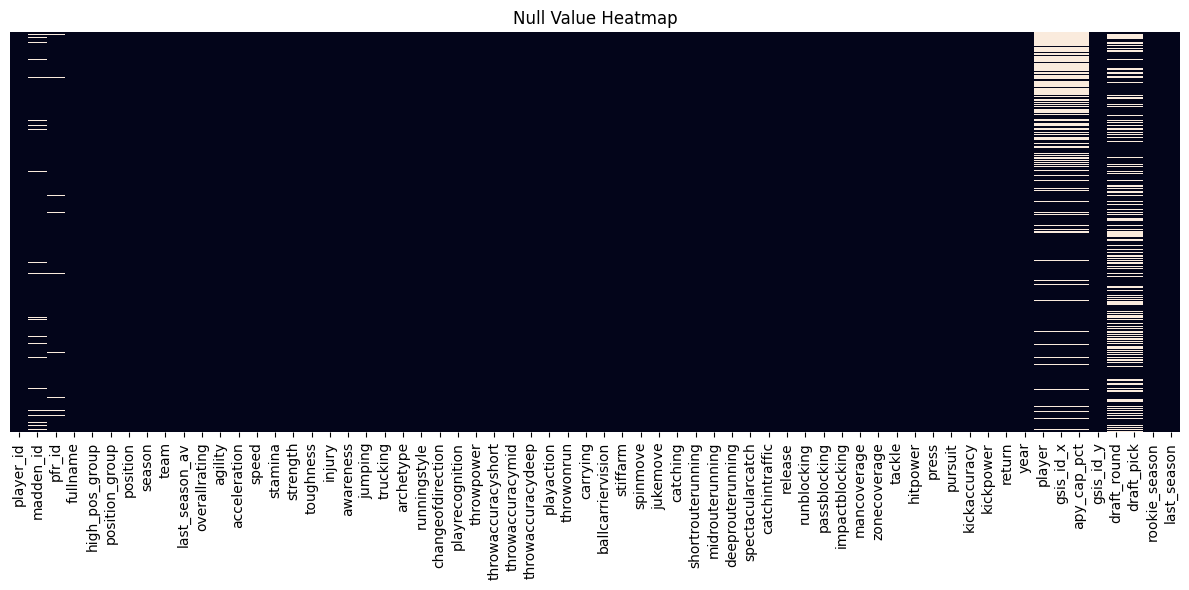

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Null Value Heatmap")
plt.tight_layout()
plt.show()

In [12]:
df = df.dropna(subset = "player")
drafted = df.query('draft_round == draft_round')
undrafted = df.query('draft_round != draft_round')

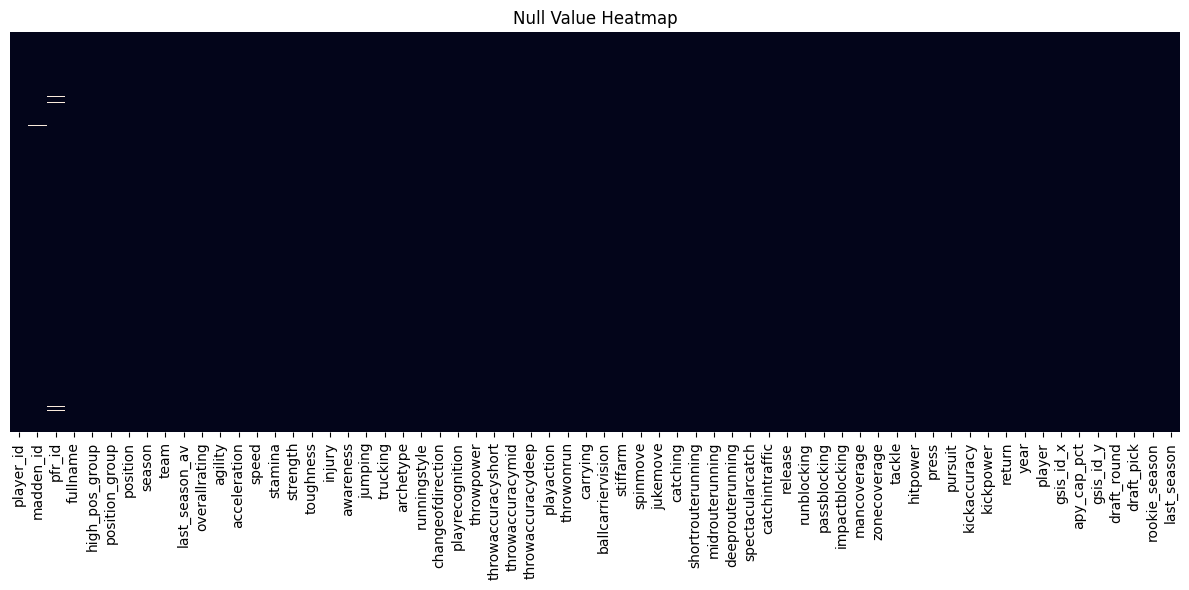

In [13]:
plt.figure(figsize=(12, 6))
sns.heatmap(drafted.isnull(), cbar=False, yticklabels=False)
plt.title("Null Value Heatmap")
plt.tight_layout()
plt.show()

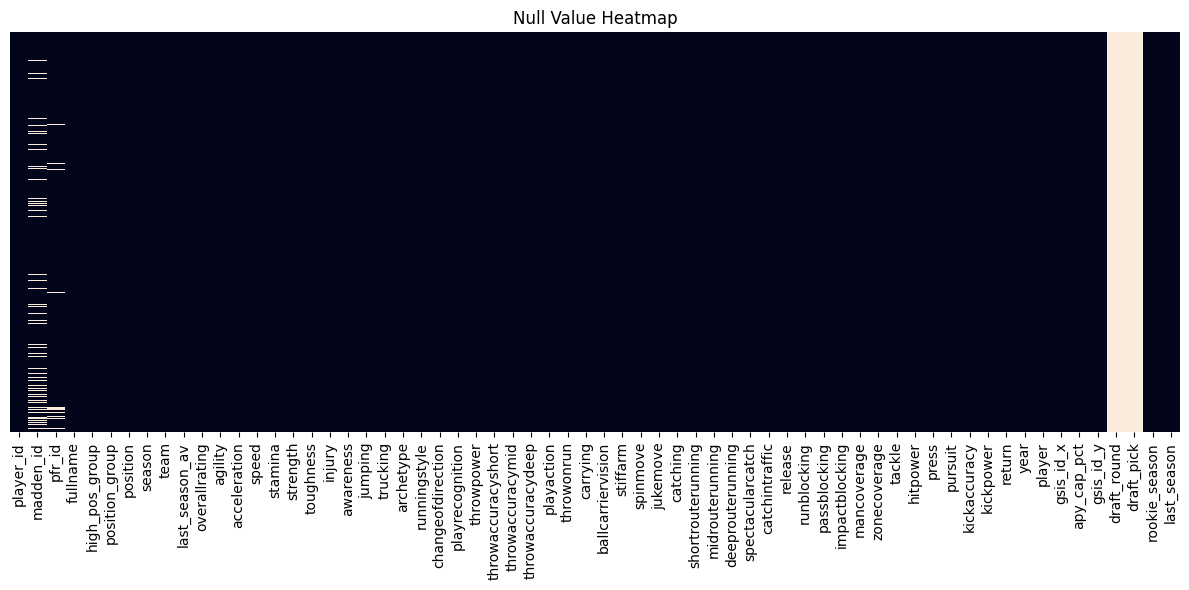

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(undrafted.isnull(), cbar=False, yticklabels=False)
plt.title("Null Value Heatmap")
plt.tight_layout()
plt.show()

## Analysis

We have two main dataframes,
- Drafted: All of the players drafted since 2001 that have a madden rating and a contract.
- Undrafted: All of the players undrafted since 2001 that have a madden rating, a contract, and were undrafted.

### How long do players from each draft round play?

In [15]:
players_small = players[["display_name", "gsis_id", "position_group", "rookie_season", "last_season", "years_of_experience", "draft_year", "draft_round", "draft_pick"]]
players_small = players_small.query("rookie_season > 2000")
players_small.head()
players_small["drafted"] = np.where(players_small["draft_round"].isna(), 0, 1)

<Axes: xlabel='draft_round', ylabel='years_of_experience'>

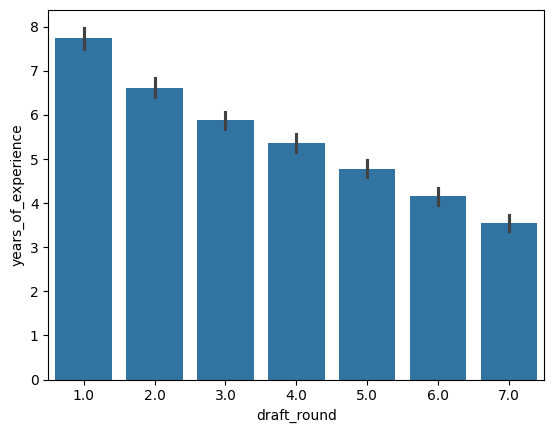

In [16]:
sns.barplot(data=players_small.query("drafted == 1"), x="draft_round", y="years_of_experience")

/tmp/ipykernel_6037/894608208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drafted['yoe'] = (drafted['year'] - drafted['rookie_season'] + 1).astype(int)


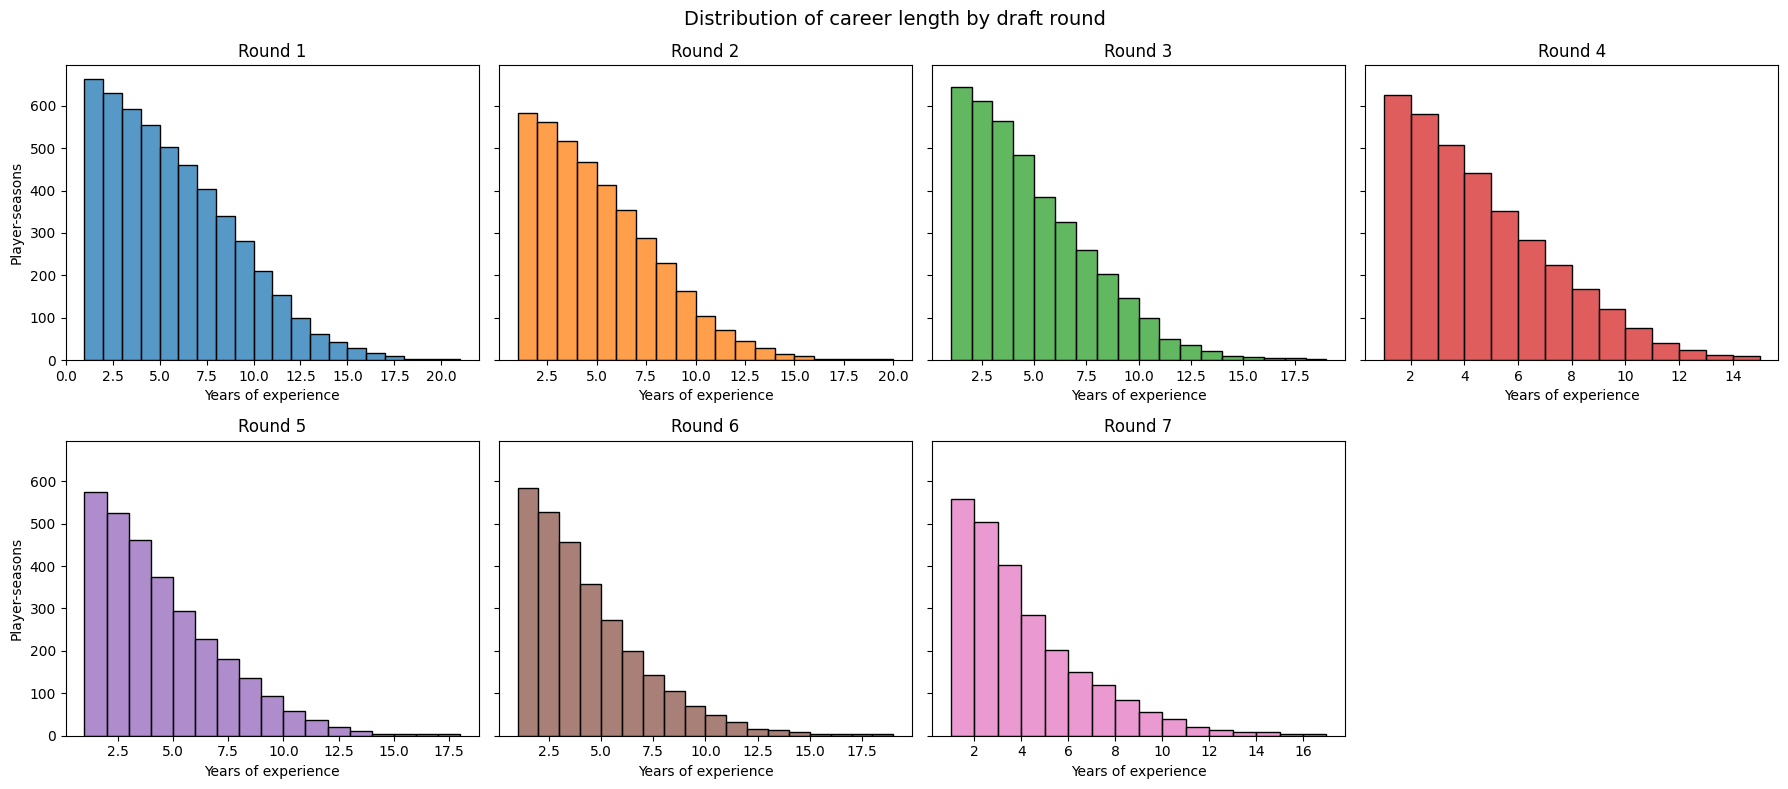

In [17]:
drafted['yoe'] = (drafted['year'] - drafted['rookie_season'] + 1).astype(int)
drafted = drafted[drafted['yoe'] >= 1]  # drop any edge-case negatives

drafted['yoe'] = (drafted['year'] - drafted['rookie_season'] + 1).astype(int)
drafted = drafted[drafted['yoe'] >= 1]  # drop any edge-case negatives

def plotAll(dataframe):
    rounds = sorted(dataframe['draft_round'].dropna().unique())
    n = len(rounds)
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
    axes = axes.flatten()

    for ax, rnd in zip(axes, rounds):
        subset = dataframe[dataframe['draft_round'] == rnd]
        sns.histplot(data=subset, x='yoe', binwidth=1, ax=ax, color=f'C{int(rnd)-1}')
        ax.set_title(f'Round {int(rnd)}')
        ax.set_xlabel('Years of experience')
        ax.set_ylabel('Player-seasons')

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle('Distribution of career length by draft round', fontsize=14)
    plt.tight_layout()
    plt.show()

plotAll(drafted)

/tmp/ipykernel_6037/2300325846.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  undrafted['yoe'] = (undrafted['year'] - undrafted['rookie_season'] + 1).astype(int)


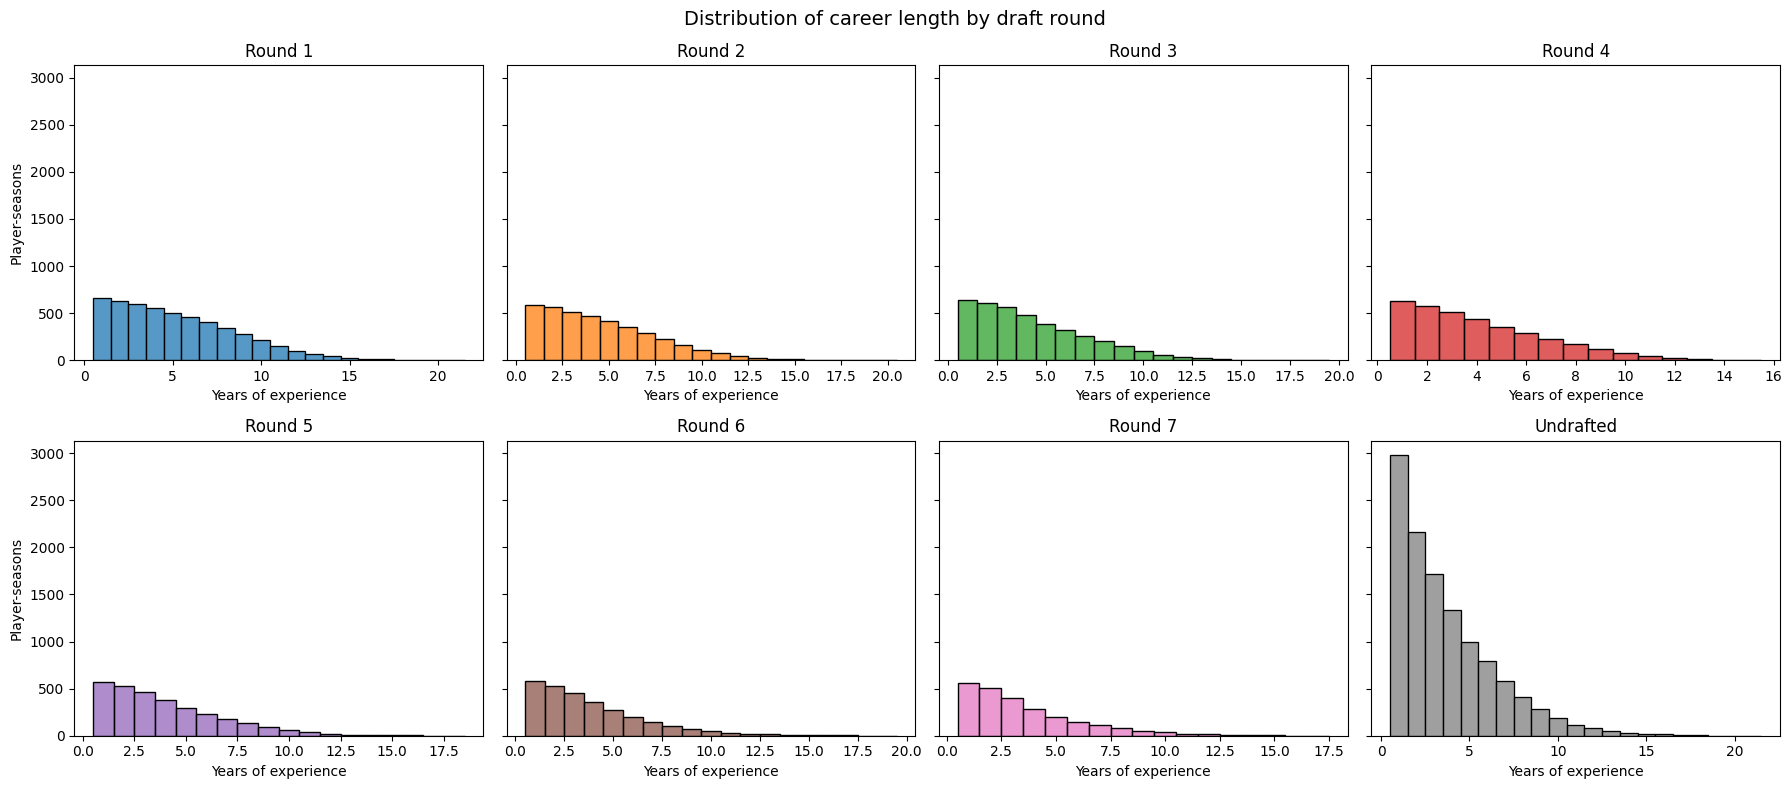

In [18]:
drafted['yoe'] = (drafted['year'] - drafted['rookie_season'] + 1).astype(int)
drafted = drafted[drafted['yoe'] >= 1]  # drop any edge-case negatives
undrafted['yoe'] = (undrafted['year'] - undrafted['rookie_season'] + 1).astype(int)
undrafted = undrafted[undrafted['yoe'] >= 1]

# Tag undrafted players as round 8 for display purposes
drafted['round_label'] = drafted['draft_round'].astype(int)
undrafted['round_label'] = 8

combined = pd.concat([drafted, undrafted], ignore_index=True)

def plotAll(dataframe):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
    axes = axes.flatten()

    round_labels = {1:'Round 1', 2:'Round 2', 3:'Round 3', 4:'Round 4',
                    5:'Round 5', 6:'Round 6', 7:'Round 7', 8:'Undrafted'}

    for ax, rnd in zip(axes, range(1, 9)):
        subset = dataframe[dataframe['round_label'] == rnd]
        sns.histplot(data=subset, x='yoe', discrete=True, ax=ax, color=f'C{rnd-1}')
        ax.set_title(round_labels[rnd])
        ax.set_xlabel('Years of experience')
        ax.set_ylabel('Player-seasons')

    fig.suptitle('Distribution of career length by draft round', fontsize=14)
    plt.tight_layout()
    plt.show()

plotAll(combined)

### Career Value

In [19]:
df["position_group"].unique()

array(['d_line', 'd_field', 'o_line', 'o_pass', 'o_rush', 'quarterback',
       'd_lb', 'o_te', 'special_teams'], dtype=object)

In [46]:
temp = df.query("year > 2005")
temp = temp.query("apy_cap_pct > 0.005")

position_summary = (
    temp.groupby(['position_group', 'year'])
    .agg(
        mean_overall  = ('overallrating',  'mean'),
        median_overall= ('overallrating',  'median'),
        mean_apy      = ('apy_cap_pct',    'mean'),
        median_apy    = ('apy_cap_pct',    'median'),
        n             = ('player_id',      'nunique'),
        sd = ("overallrating", "std"),
    )
    .reset_index()
    .round(3)
)

display(position_summary)

,position_group,year,mean_overall,median_overall,mean_apy,median_apy,n,sd
0,d_field,2006,83.742,82.240,0.028,0.024,27,6.514
1,d_field,2007,85.074,83.000,0.030,0.020,35,7.086
2,d_field,2008,84.950,85.000,0.033,0.027,45,7.899
3,d_field,2009,80.156,80.285,0.030,0.020,58,6.656
4,d_field,2010,80.901,82.000,0.030,0.019,73,8.234
...,...,...,...,...,...,...,...,...
175,special_teams,2021,76.017,75.000,0.012,0.010,63,4.486
176,special_teams,2022,76.073,75.436,0.013,0.011,65,4.178
177,special_teams,2023,76.072,76.000,0.013,0.010,64,4.080
178,special_teams,2024,77.370,77.000,0.015,0.014,57,3.222


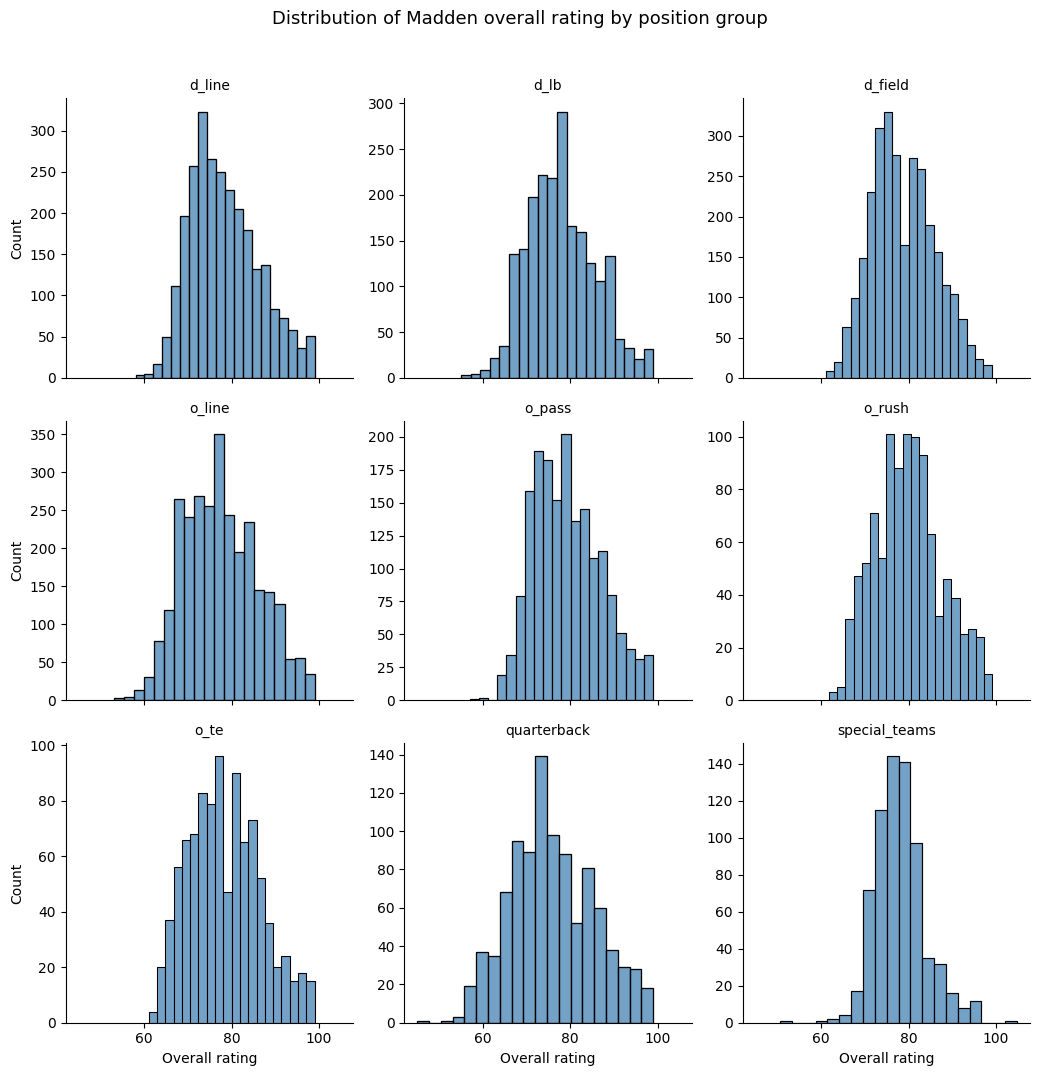

In [31]:
g1 = sns.FacetGrid(
    temp.dropna(subset=['overallrating', 'position_group']),
    col='position_group',
    col_wrap=3,
    height=3.5,
    sharey=False,
    sharex=True,
)
g1.map(sns.histplot, 'overallrating', bins=20, color='steelblue')
g1.set_axis_labels('Overall rating', 'Count')
g1.set_titles(col_template='{col_name}')
g1.figure.suptitle('Distribution of Madden overall rating by position group', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

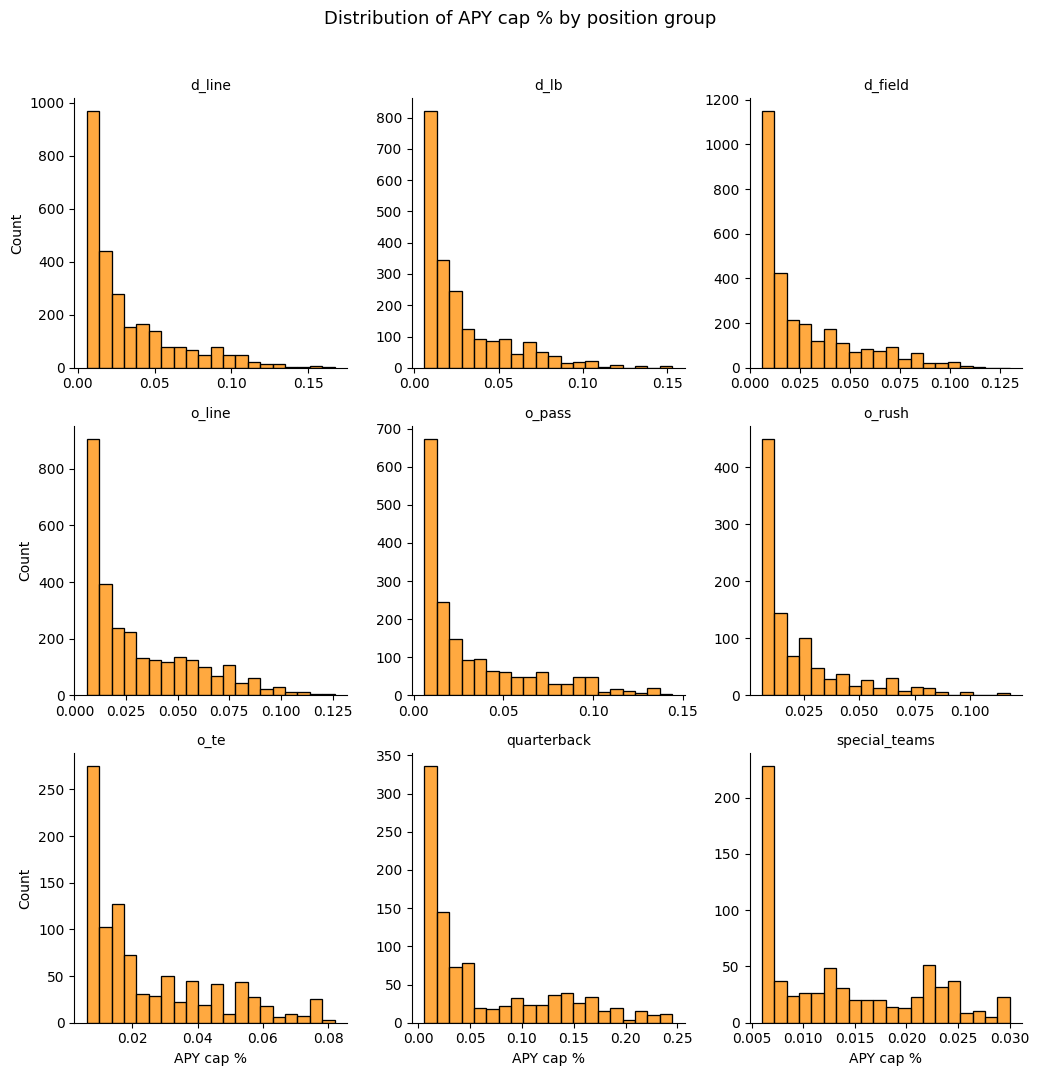

In [32]:
# ── Graph 2: APY cap % distribution by position group ────────────────────────
g2 = sns.FacetGrid(
    temp.dropna(subset=['apy_cap_pct', 'position_group']),
    col='position_group',
    col_wrap=3,
    height=3.5,
    sharey=False,
    sharex=False,   # APY ranges differ a lot by position, so let each panel breathe
)
g2.map(sns.histplot, 'apy_cap_pct', bins=20, color='darkorange')
g2.set_axis_labels('APY cap %', 'Count')
g2.set_titles(col_template='{col_name}')
g2.figure.suptitle('Distribution of APY cap % by position group', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

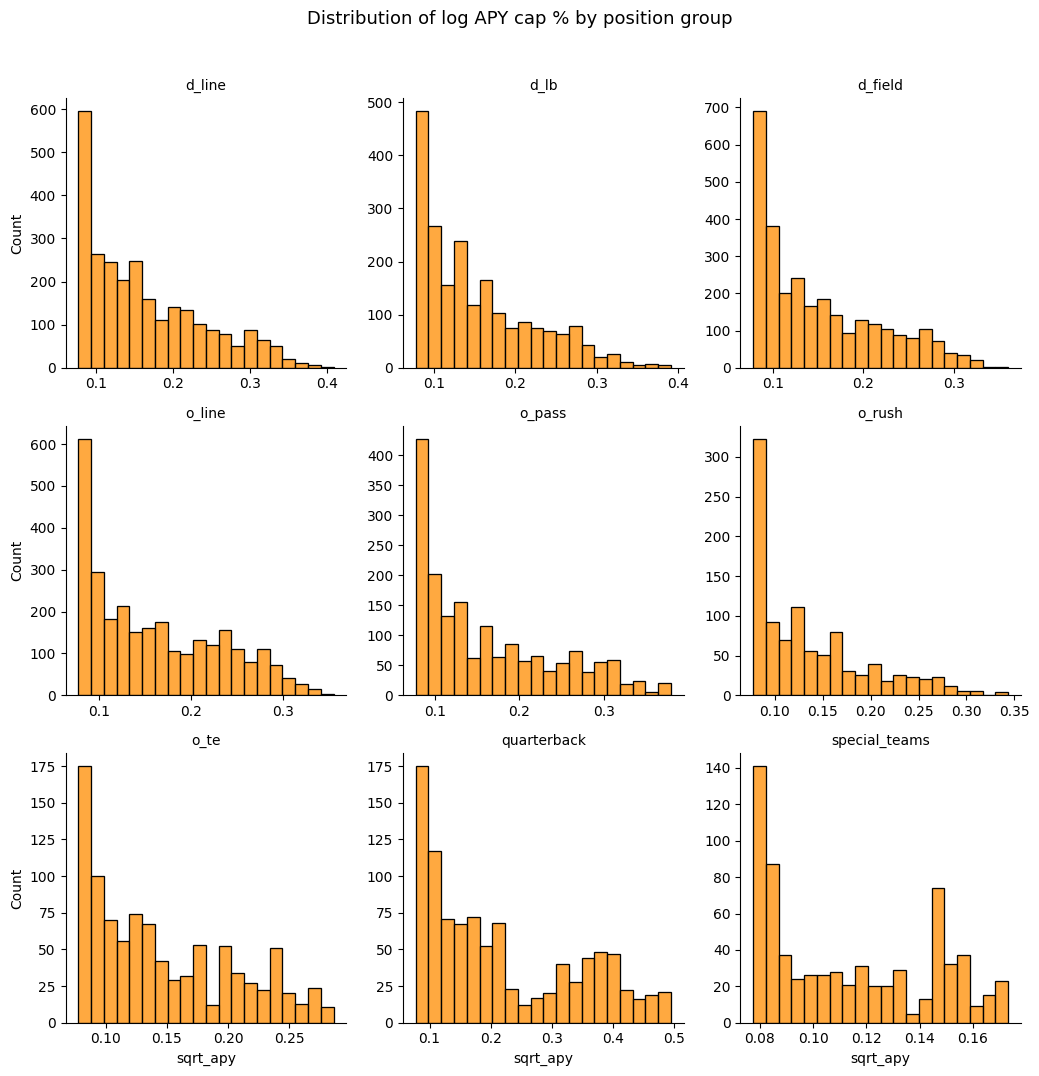

In [36]:
temp['sqrt_apy'] = np.sqrt(temp['apy_cap_pct'])

g3 = sns.FacetGrid(
    temp.dropna(subset=['sqrt_apy', 'position_group']),
    col='position_group',
    col_wrap=3,
    height=3.5,
    sharey=False,
    sharex=False,
)
g3.map(sns.histplot, 'sqrt_apy', bins=20, color='darkorange')
g3.set_axis_labels('sqrt_apy', 'Count')
g3.set_titles(col_template='{col_name}')
g3.figure.suptitle('Distribution of log APY cap % by position group', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [47]:
position_summary
temp_small = temp[["fullname", "player_id", "position_group", "position", "season", "overallrating", "rookie_season", "last_season", "apy_cap_pct"]]
temp_small = temp_small.merge(position_summary, left_on=["position_group", "season"], right_on=["position_group", "year"], how="left")

In [50]:
temp_small["z_overall"] = (temp_small["overallrating"] - temp_small["median_overall"]) / temp_small["sd"]

In [51]:
temp_small

,fullname,player_id,position_group,position,season,overallrating,rookie_season,last_season,apy_cap_pct,year,mean_overall,median_overall,mean_apy,median_apy,n,sd,z_overall
0,Jason Babin,00-0022695,d_line,DE,2006,83.000000,2004.0,2015.0,0.017,2006,83.862,83.0,0.034,0.023,29,8.122,0.000000
1,Brett Keisel,00-0021344,d_line,DE,2006,79.000000,2002.0,2014.0,0.032,2006,83.862,83.0,0.034,0.023,29,8.122,-0.492490
2,Isaac Sopoaga,00-0022863,d_line,NT,2006,76.000000,2004.0,2013.0,0.006,2006,83.862,83.0,0.034,0.023,29,8.122,-0.861857
3,Justin Tuck,00-0023509,d_line,DE,2006,75.000000,2005.0,2015.0,0.006,2006,83.862,83.0,0.034,0.023,29,8.122,-0.984979
4,Dwan Edwards,00-0022750,d_line,DT,2006,72.000000,2004.0,2015.0,0.007,2006,83.862,83.0,0.034,0.023,29,8.122,-1.354346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15921,Jason Sanders,00-0034794,special_teams,K,2025,77.000000,2018.0,2026.0,0.024,2025,76.741,77.0,0.013,0.011,47,4.192,0.000000
15922,Rigoberto Sanchez,00-0033269,special_teams,P,2025,77.000000,2017.0,2026.0,0.010,2025,76.741,77.0,0.013,0.011,47,4.192,0.000000
15923,Wil Lutz,00-0032569,special_teams,K,2025,77.000000,2016.0,2026.0,0.019,2025,76.741,77.0,0.013,0.011,47,4.192,0.000000
15924,Riley Dixon,00-0032943,special_teams,P,2025,76.000000,2016.0,2026.0,0.011,2025,76.741,77.0,0.013,0.011,47,4.192,-0.238550


In [ ]:
# def position_group_percentile(df):
#     df = df.copy()
#     df['apy_pct_rank'] = df.groupby('position_group')['apy_cap_pct'].transform(
#         lambda x: x.rank(pct=True, method='average')  # pct=True gives 0–1 percentile
#     )

#     # Optional: scale to 0–100 for readability
#     df['apy_percentile'] = (df['apy_pct_rank'] * 100).round(1)

#     return df

# df = position_group_percentile(df)

In [53]:
position_summary

,position_group,year,mean_overall,median_overall,mean_apy,median_apy,n,sd
0,d_field,2006,83.742,82.240,0.028,0.024,27,6.514
1,d_field,2007,85.074,83.000,0.030,0.020,35,7.086
2,d_field,2008,84.950,85.000,0.033,0.027,45,7.899
3,d_field,2009,80.156,80.285,0.030,0.020,58,6.656
4,d_field,2010,80.901,82.000,0.030,0.019,73,8.234
...,...,...,...,...,...,...,...,...
175,special_teams,2021,76.017,75.000,0.012,0.010,63,4.486
176,special_teams,2022,76.073,75.436,0.013,0.011,65,4.178
177,special_teams,2023,76.072,76.000,0.013,0.010,64,4.080
178,special_teams,2024,77.370,77.000,0.015,0.014,57,3.222


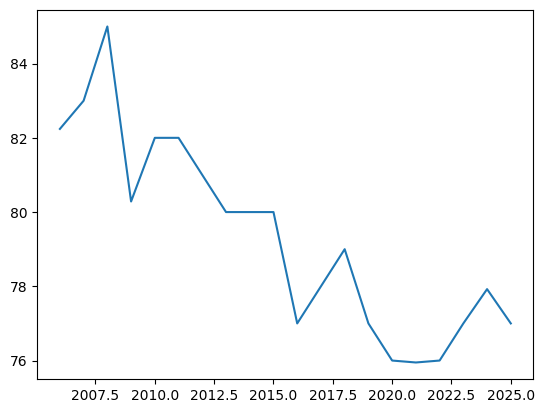

In [63]:
db = position_summary.query("position_group == 'd_field'")
lb = position_summary.query("position_group == 'd_lb'")
dl = position_summary.query("position_group == 'd_line'")
ol = position_summary.query("position_group == 'o_line'")
wr = position_summary.query("position_group == 'o_pass'")
rb = position_summary.query("position_group == 'o_rush'")
te = position_summary.query("position_group == 'o_te'")
qb = position_summary.query("position_group == 'quarterback'")
st = position_summary.query("position_group == 'special_teams'")

plt.plot(db["year"], db["median_overall"])

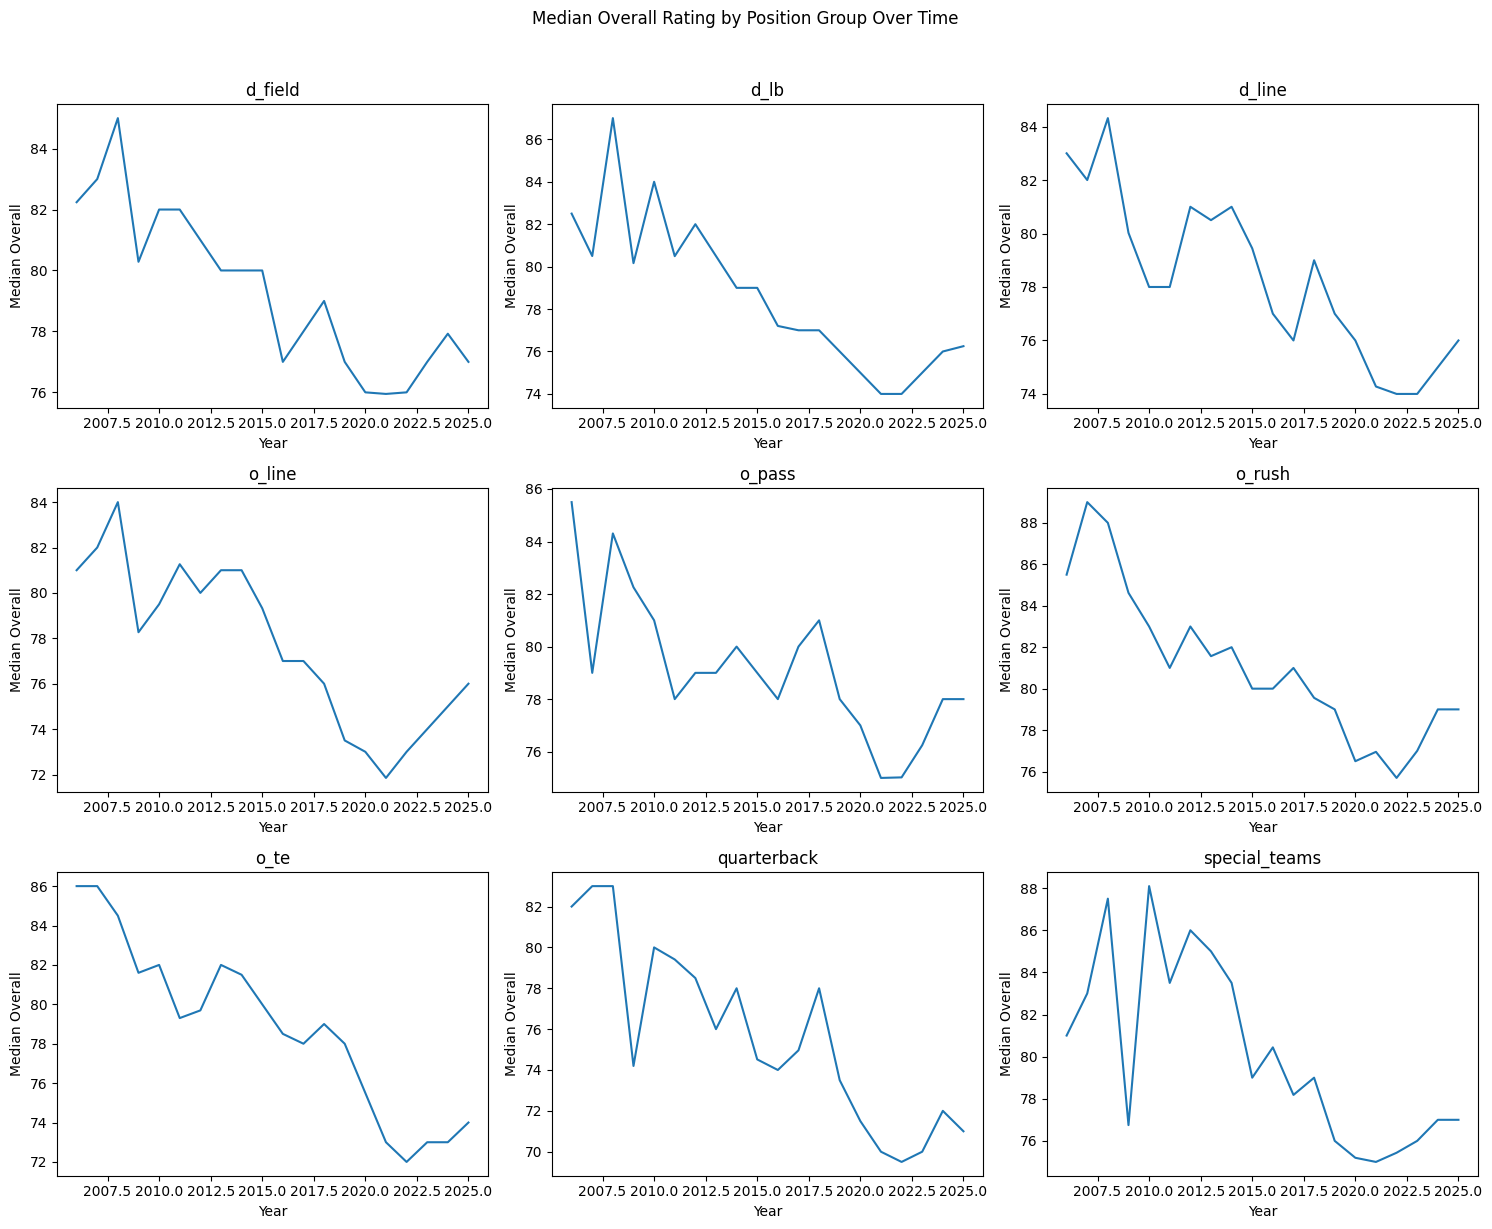

In [68]:
def plotAll(dataframe):
    groups = dataframe["position_group"].unique()
    n = len(groups)

    # Build a grid (e.g., 3 columns)
    ncols = 3
    nrows = -(-n // ncols)  # ceiling division

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4), sharey=False)
    axes = axes.flatten()  # make indexing easy

    for i, pos in enumerate(sorted(groups)):
        subset = dataframe.query("position_group == @pos")
        axes[i].plot(subset["year"], subset["median_overall"])
        axes[i].set_title(pos)
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel("Median Overall")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Median Overall Rating by Position Group Over Time", y=1.02)
    plt.tight_layout()
    plt.show()

plotAll(position_summary)

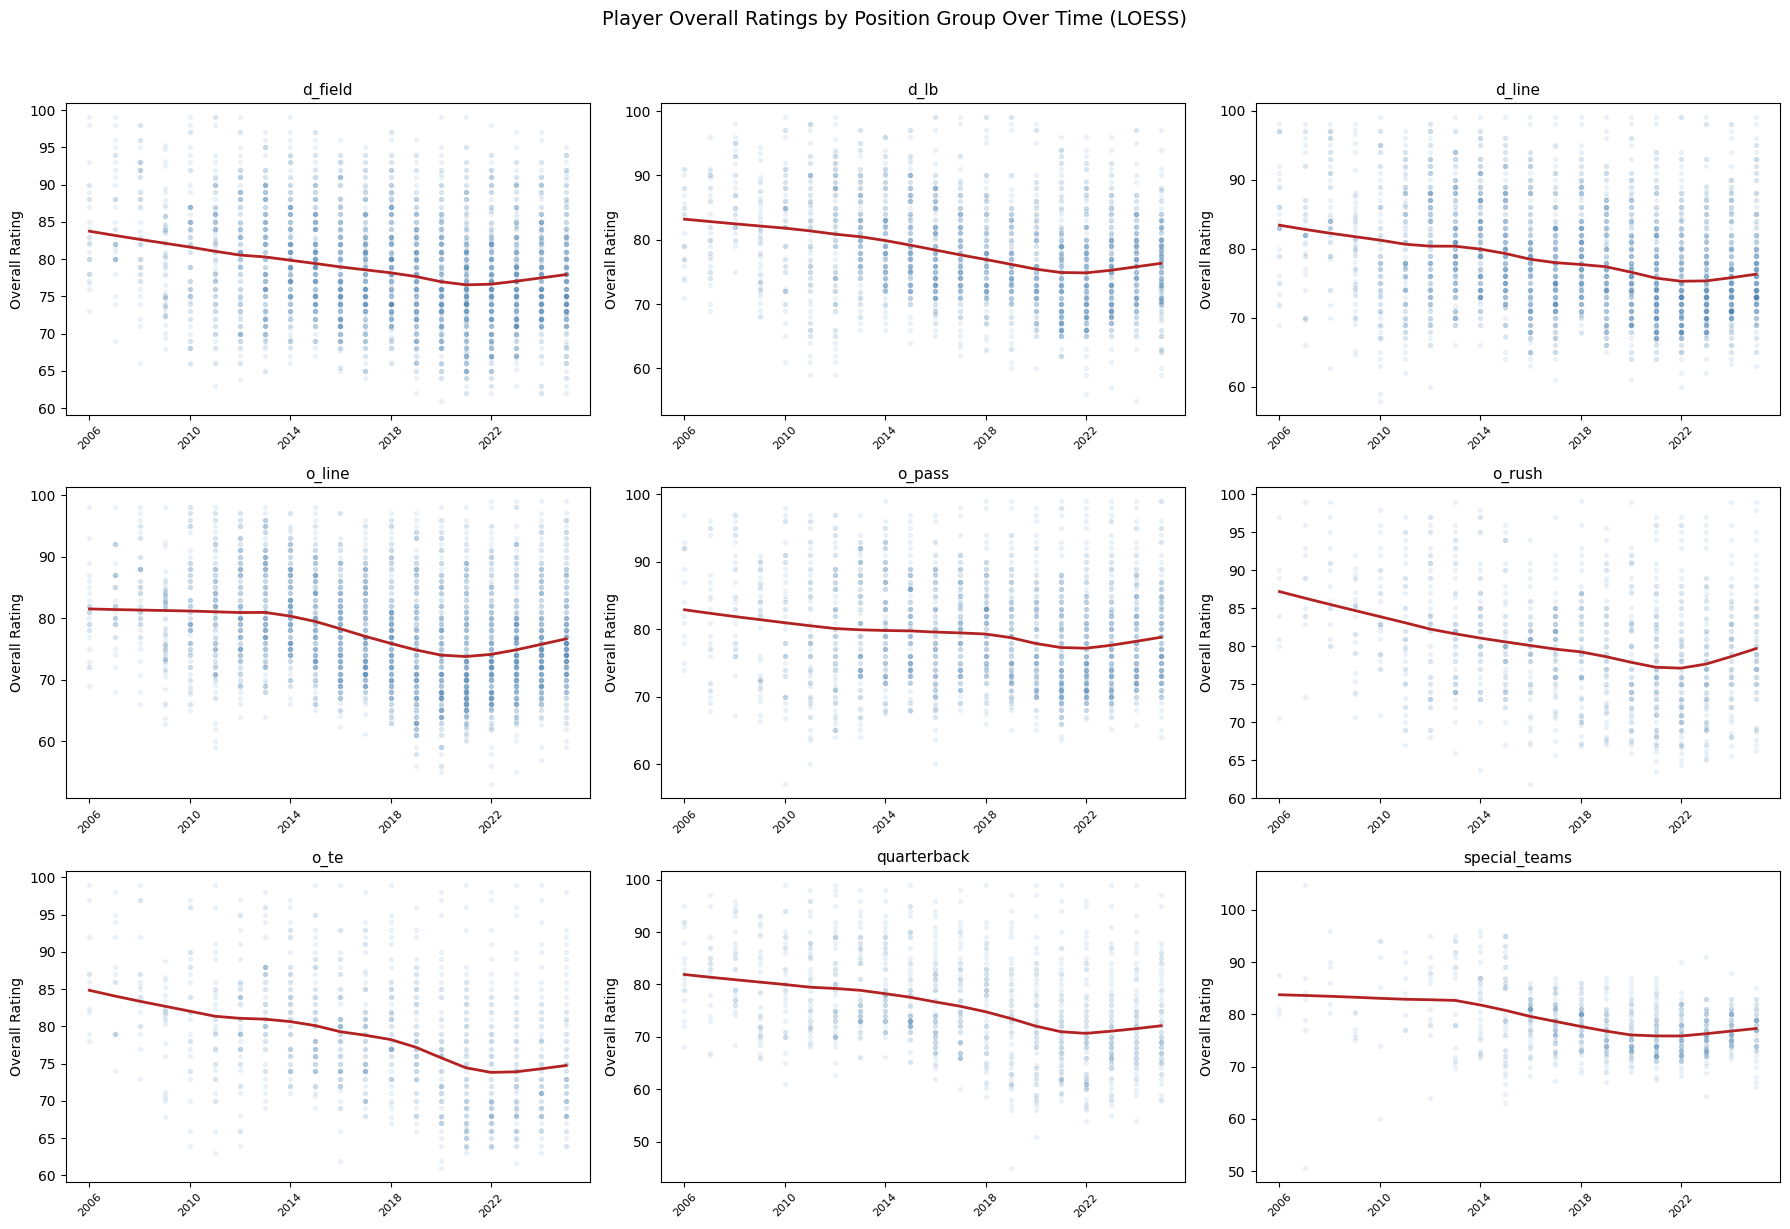

In [70]:
import statsmodels.api as sm

def plotAll(dataframe):
    groups = sorted(dataframe["position_group"].unique())
    n = len(groups)
    ncols = 3
    nrows = -(-n // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=False)
    axes = axes.flatten()

    for i, pos in enumerate(groups):
        ax = axes[i]
        subset = dataframe.query("position_group == @pos").sort_values("year")

        x = subset["year"].values
        y = subset["overallrating"].values  # individual player ratings now

        # Raw scatter — use small alpha since lots of points
        ax.scatter(x, y, alpha=0.08, s=8, color="steelblue")

        # LOESS on all individual points
        lowess = sm.nonparametric.lowess(y, x, frac=0.4)
        ax.plot(lowess[:, 0], lowess[:, 1], color="firebrick", linewidth=2)

        ax.set_title(pos, fontsize=11)
        ax.set_ylabel("Overall Rating")
        ax.set_xlabel("")

        year_min, year_max = int(x.min()), int(x.max())
        ax.set_xticks(range(year_min, year_max + 1, 4))
        ax.tick_params(axis='x', rotation=45, labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Player Overall Ratings by Position Group Over Time (LOESS)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plotAll(temp_small)

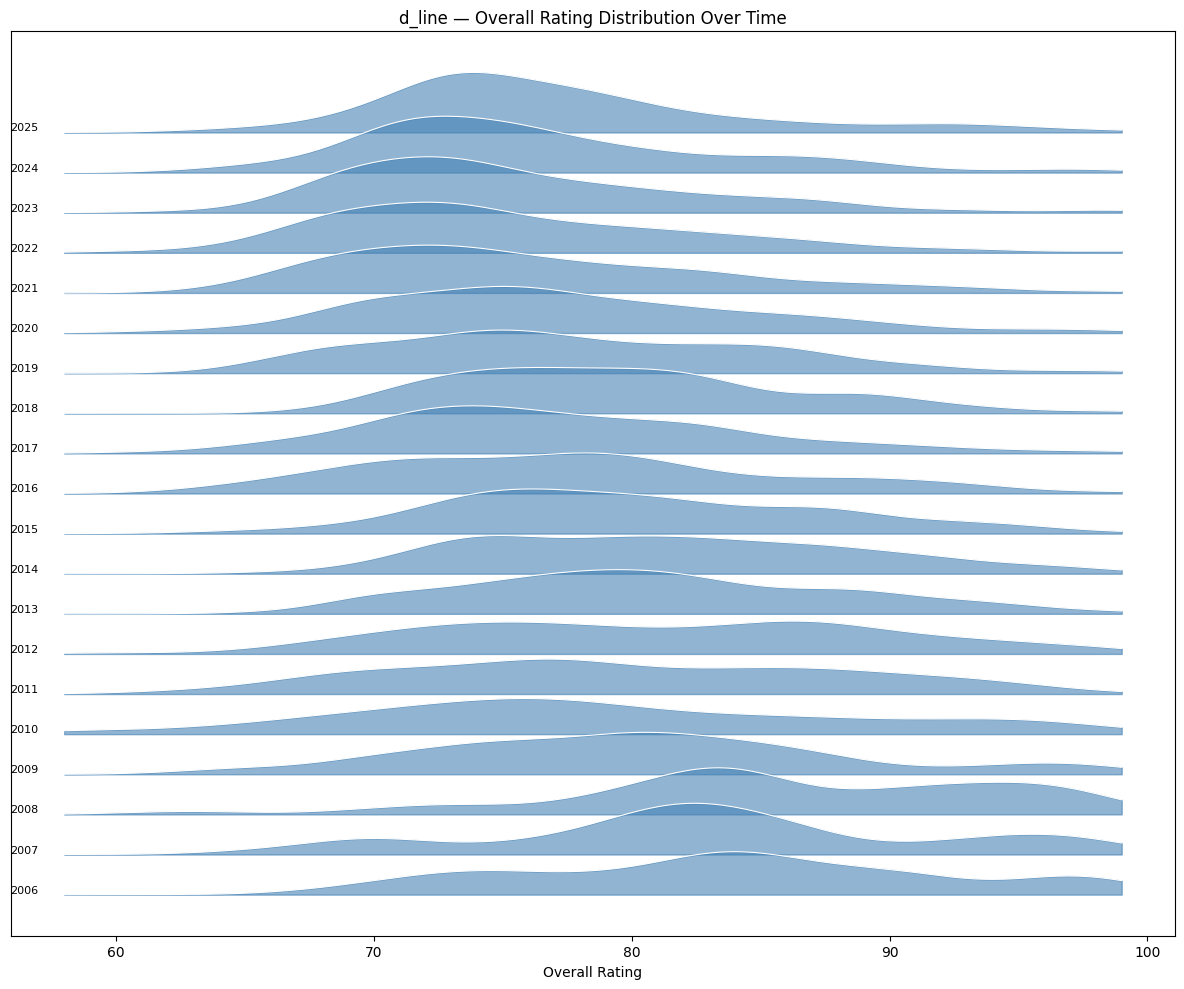

In [71]:
from matplotlib.collections import PolyCollection

def plot_ridge(dataframe, position):
    subset = dataframe.query("position_group == @position").sort_values("year")
    years = sorted(subset["year"].unique())

    fig, ax = plt.subplots(figsize=(12, len(years) * 0.5))

    for i, year in enumerate(years):
        ratings = subset.query("year == @year")["overallrating"].values

        from scipy.stats import gaussian_kde
        kde = gaussian_kde(ratings, bw_method=0.3)
        x_range = np.linspace(subset["overallrating"].min(), subset["overallrating"].max(), 200)
        density = kde(x_range)

        # Offset each year upward
        offset = i * 1.5
        ax.fill_between(x_range, offset, offset + density * 30, alpha=0.6, color="steelblue")
        ax.plot(x_range, offset + density * 30, color="white", linewidth=0.8)
        ax.text(subset["overallrating"].min() - 1, offset, str(int(year)),
                ha="right", va="bottom", fontsize=8)

    ax.set_xlabel("Overall Rating")
    ax.set_yticks([])
    ax.set_title(f"{position} — Overall Rating Distribution Over Time")
    plt.tight_layout()
    plt.show()

plot_ridge(temp_small, "d_line")

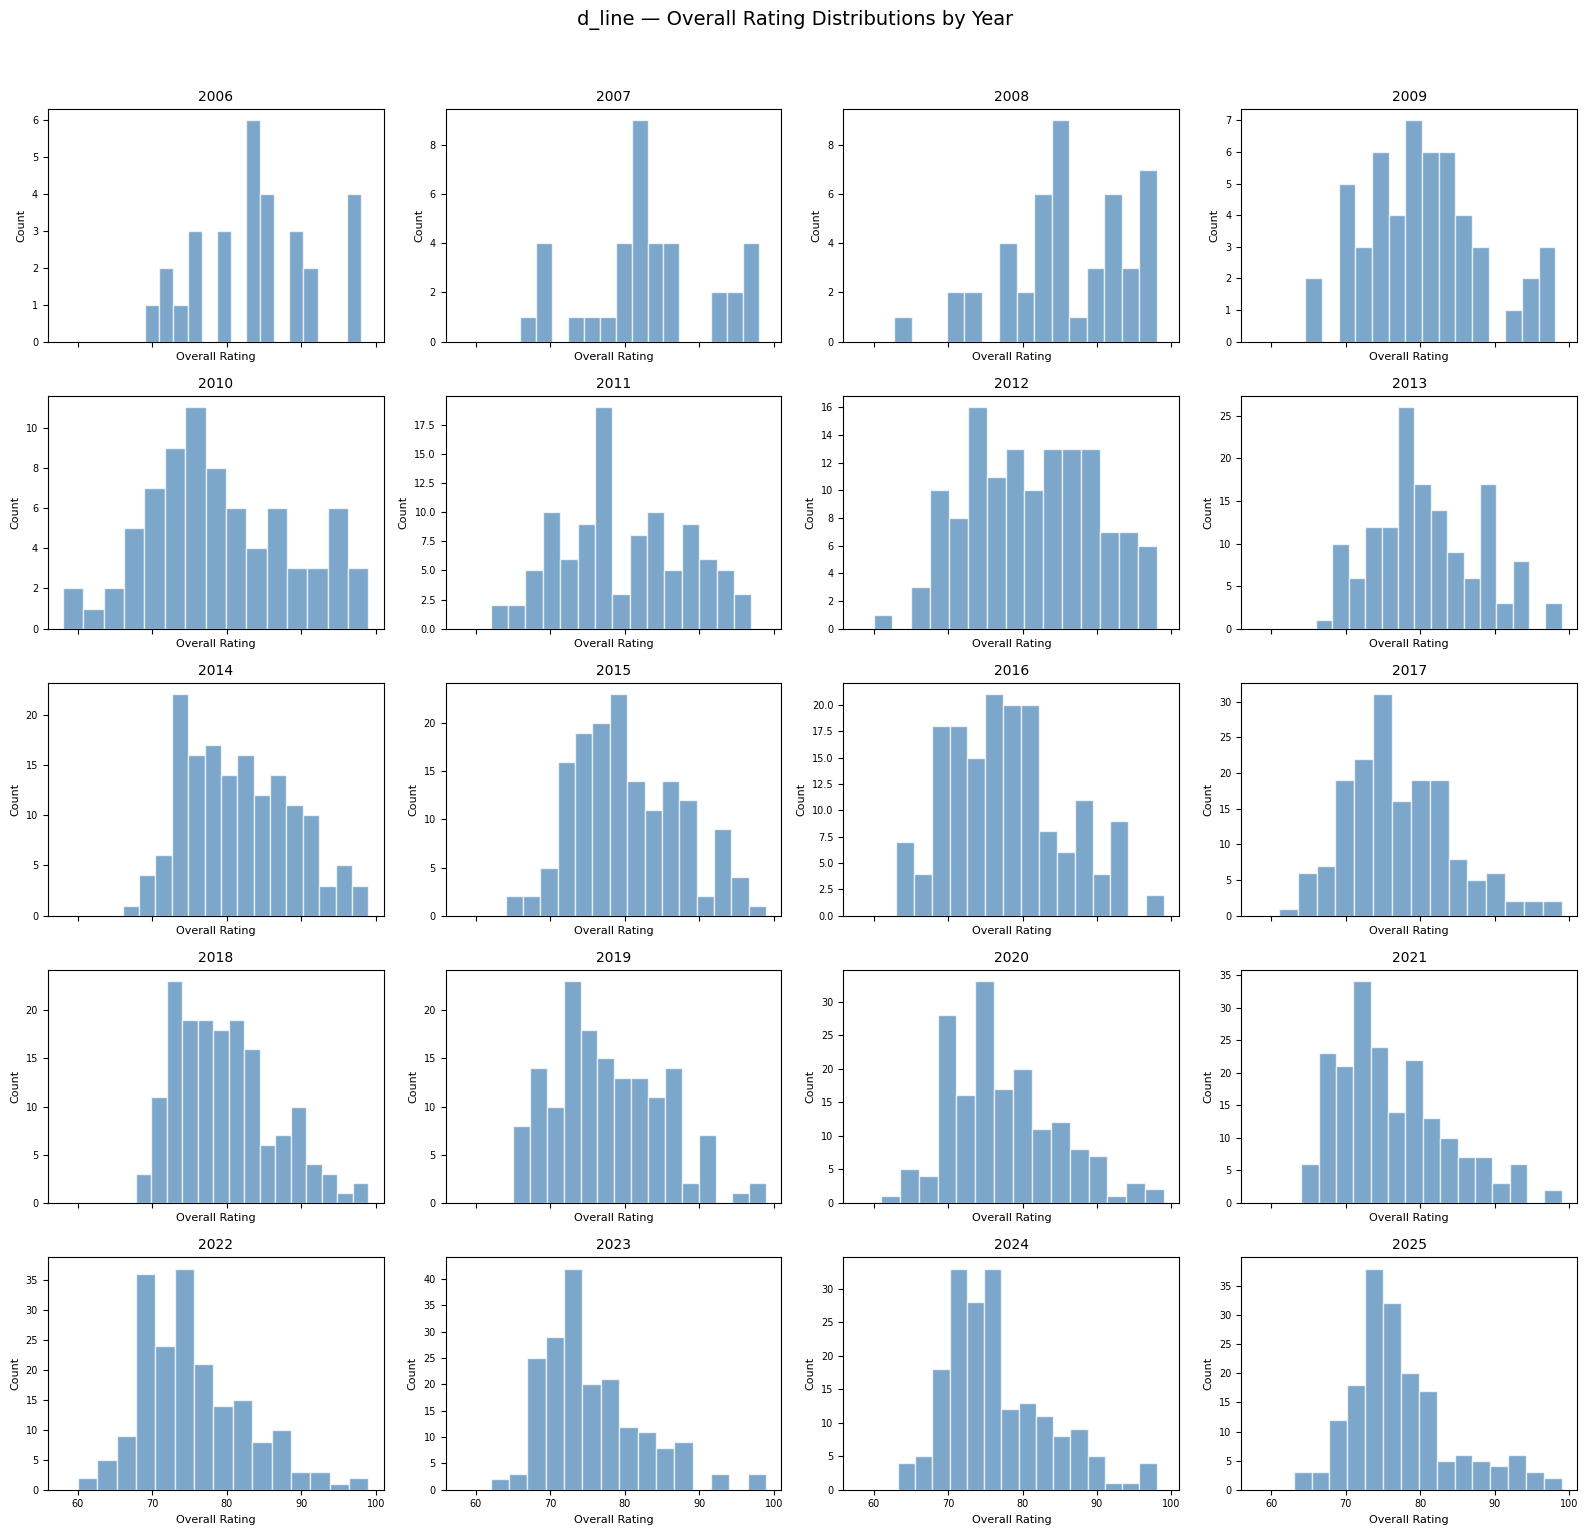

In [72]:
def plot_yearly_hist(dataframe, position):
    subset = dataframe.query("position_group == @position").sort_values("year")
    years = sorted(subset["year"].unique())

    ncols = 4
    nrows = -(-len(years) // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, nrows * 3), sharey=False, sharex=True)
    axes = axes.flatten()

    for i, year in enumerate(years):
        ax = axes[i]
        ratings = subset.query("year == @year")["overallrating"].values

        ax.hist(ratings, bins=15, color="steelblue", alpha=0.7, edgecolor="white")
        ax.set_title(str(int(year)), fontsize=10)
        ax.set_xlabel("Overall Rating", fontsize=8)
        ax.set_ylabel("Count", fontsize=8)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{position} — Overall Rating Distributions by Year", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_yearly_hist(temp_small, "d_line")

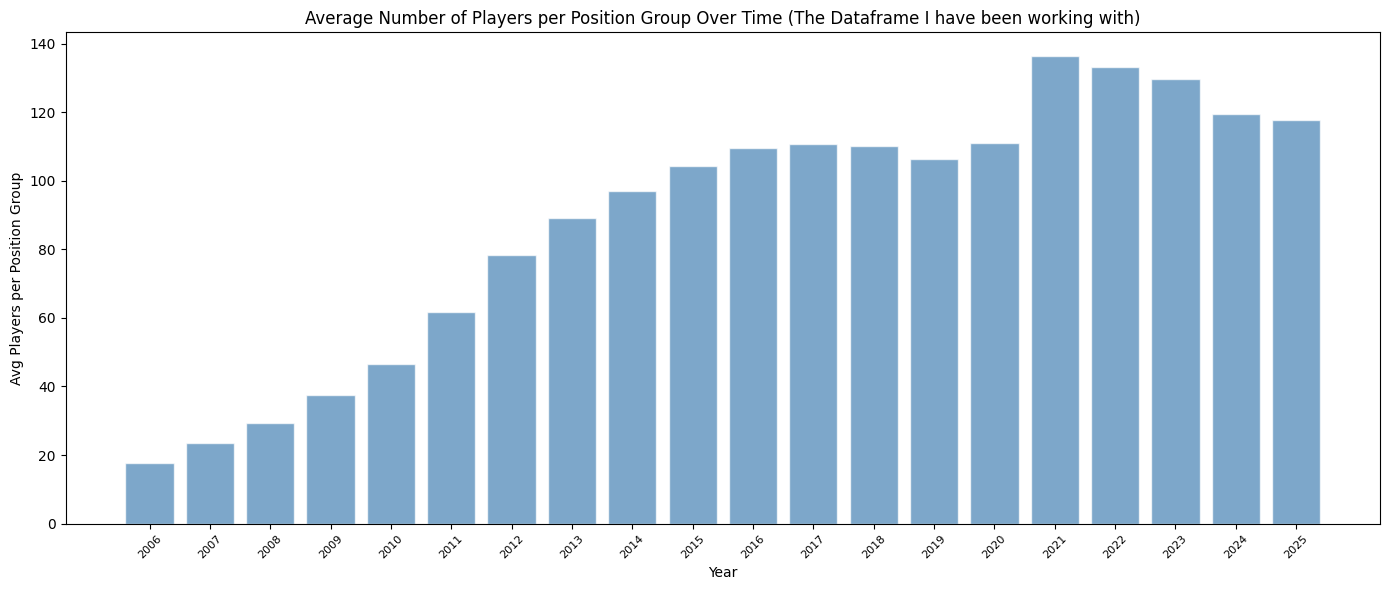

In [84]:
def plot_observation_counts(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))

    yearly_counts = dataframe.groupby("year")["n"].mean()  # n is already the count per group

    ax.bar(yearly_counts.index.astype(int), yearly_counts.values, color="steelblue", alpha=0.7, edgecolor="white")
    ax.set_xlabel("Year")
    ax.set_ylabel("Avg Players per Position Group")
    ax.set_xticks(yearly_counts.index.astype(int))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_title("Average Number of Players per Position Group Over Time (The Dataframe I have been working with)")
    plt.tight_layout()
    plt.show()

plot_observation_counts(position_summary)

In [77]:
position_summary_madden_long = (
    madden_long
    .groupby(["position_group", "year"])["overallrating"]
    .agg(
        mean_overall="mean",
        median_overall="median",
        n="count",
        sd="std"
    )
    .reset_index()
)

position_summary_madden_long

,position_group,year,mean_overall,median_overall,n,sd
0,d_field,2001,68.664064,69.000000,365,10.288611
1,d_field,2002,67.711419,66.000000,362,11.526267
2,d_field,2003,71.794387,70.000000,378,10.003572
3,d_field,2004,74.369028,72.733159,373,9.849298
4,d_field,2005,75.305321,74.000000,389,9.393804
...,...,...,...,...,...,...
219,special_teams,2021,73.408182,72.658907,146,4.759313
220,special_teams,2022,73.720232,73.000000,137,4.613147
221,special_teams,2023,74.168932,74.000000,122,4.792615
222,special_teams,2024,73.902958,74.000000,140,4.826510


In [81]:
structure = madden_long.groupby("year")["player_id"].count().reset_index(name="n")

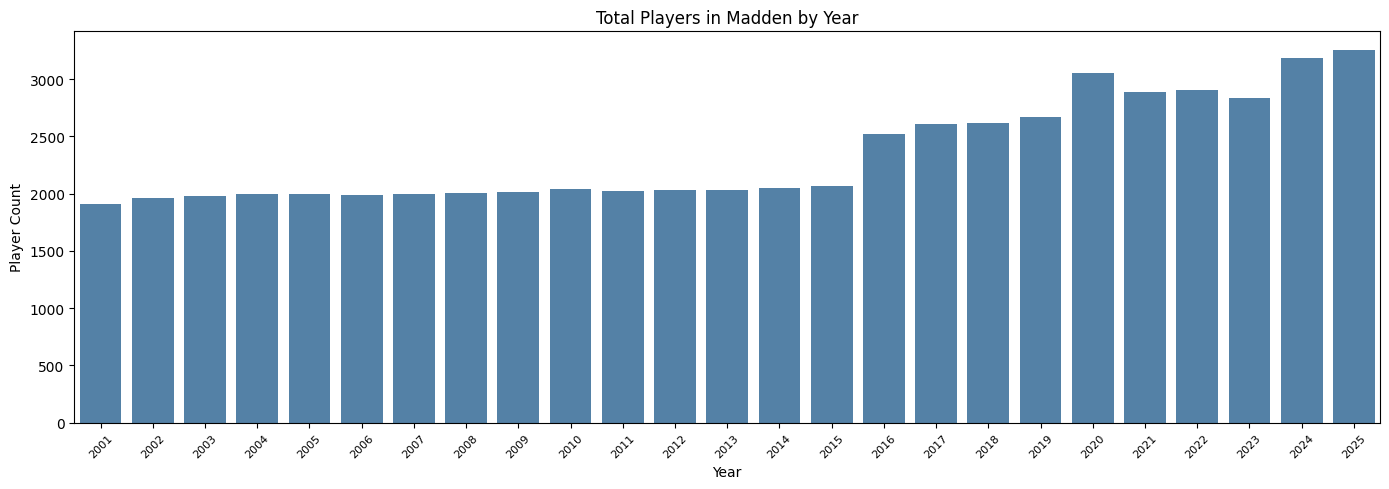

In [83]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.barplot(data=structure, x="year", y="n", color="steelblue", ax=ax)

ax.set_xlabel("Year")
ax.set_ylabel("Player Count")
ax.set_title("Total Players in Madden by Year (large madden)")
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

In [86]:
new_summary = (
    madden_long.groupby(['position_group', 'year'])
    .agg(
        mean_overall  = ('overallrating',  'mean'),
        median_overall= ('overallrating',  'median'),
        n             = ('player_id',      'nunique'),
        overall_sd = ("overallrating", "std"),
    )
    .reset_index()
    .round(3)
)

display(new_summary)

,position_group,year,mean_overall,median_overall,n,overall_sd
0,d_field,2001,68.664,69.000,353,10.289
1,d_field,2002,67.711,66.000,352,11.526
2,d_field,2003,71.794,70.000,344,10.004
3,d_field,2004,74.369,72.733,351,9.849
4,d_field,2005,75.305,74.000,365,9.394
...,...,...,...,...,...,...
219,special_teams,2021,73.408,72.659,146,4.759
220,special_teams,2022,73.720,73.000,137,4.613
221,special_teams,2023,74.169,74.000,122,4.793
222,special_teams,2024,73.903,74.000,140,4.827


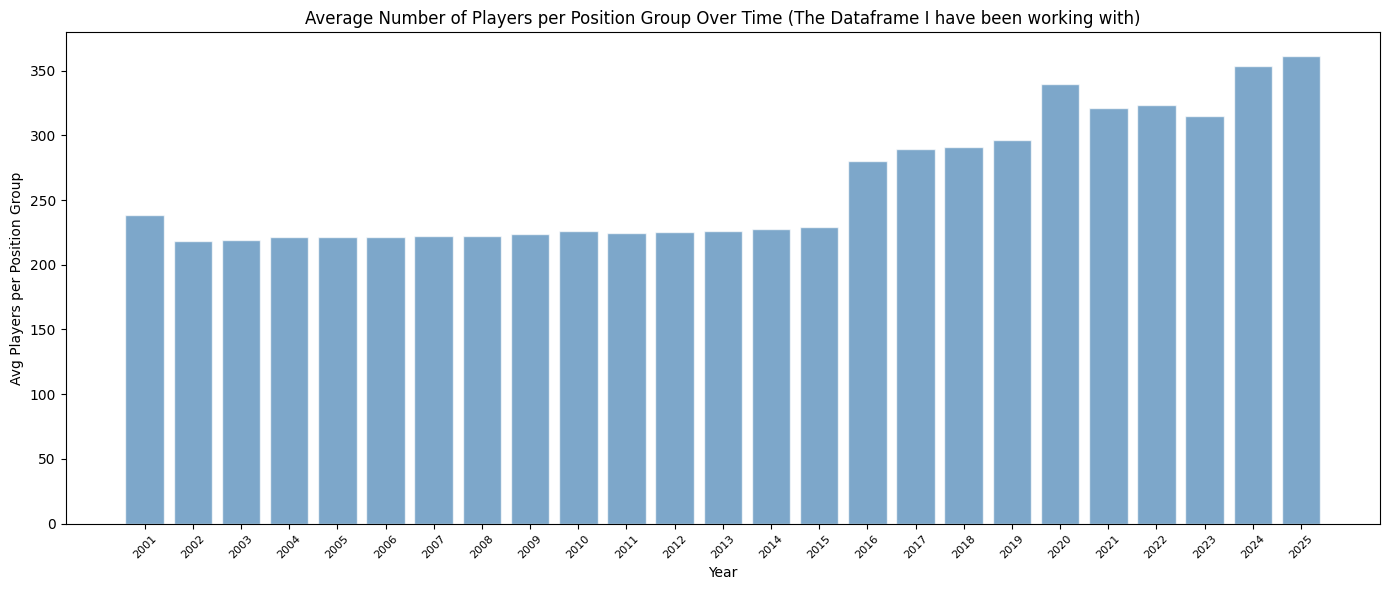

In [87]:
def plot_observation_counts(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))

    yearly_counts = dataframe.groupby("year")["n"].mean()  # n is already the count per group

    ax.bar(yearly_counts.index.astype(int), yearly_counts.values, color="steelblue", alpha=0.7, edgecolor="white")
    ax.set_xlabel("Year")
    ax.set_ylabel("Avg Players per Position Group")
    ax.set_xticks(yearly_counts.index.astype(int))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_title("Average Number of Players per Position Group Over Time (The historical dataframe)")
    plt.tight_layout()
    plt.show()

plot_observation_counts(new_summary)

In [90]:
madden_short = madden_long[["fullname", "player_id", "position_group", "overallrating", "year"]]
madden_short = madden_short.merge(new_summary, left_on=["position_group", "year"], right_on=["position_group", "year"], how="left")
madden_short

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd
0,Shane Dronett,00-0004543,d_line,75.000000,2001,69.036,67.441,321,10.346
1,Jason Peter,00-0012842,d_line,74.000000,2001,69.036,67.441,321,10.346
2,Leonard Little,00-0009978,d_line,73.000000,2001,69.036,67.441,321,10.346
3,Junior Bryant,00-0002142,d_line,72.000000,2001,69.036,67.441,321,10.346
4,Reinard Wilson,00-0018054,d_line,69.000000,2001,69.036,67.441,321,10.346
...,...,...,...,...,...,...,...,...,...
62325,Jake Bates,00-0039172,special_teams,76.000000,2025,73.079,74.000,136,5.916
62326,Riley Dixon,00-0032943,special_teams,76.000000,2025,73.079,74.000,136,5.916
62327,Tory Taylor,00-0039745,special_teams,75.000000,2025,73.079,74.000,136,5.916
62328,Blake Grupe,00-0038905,special_teams,73.000000,2025,73.079,74.000,136,5.916


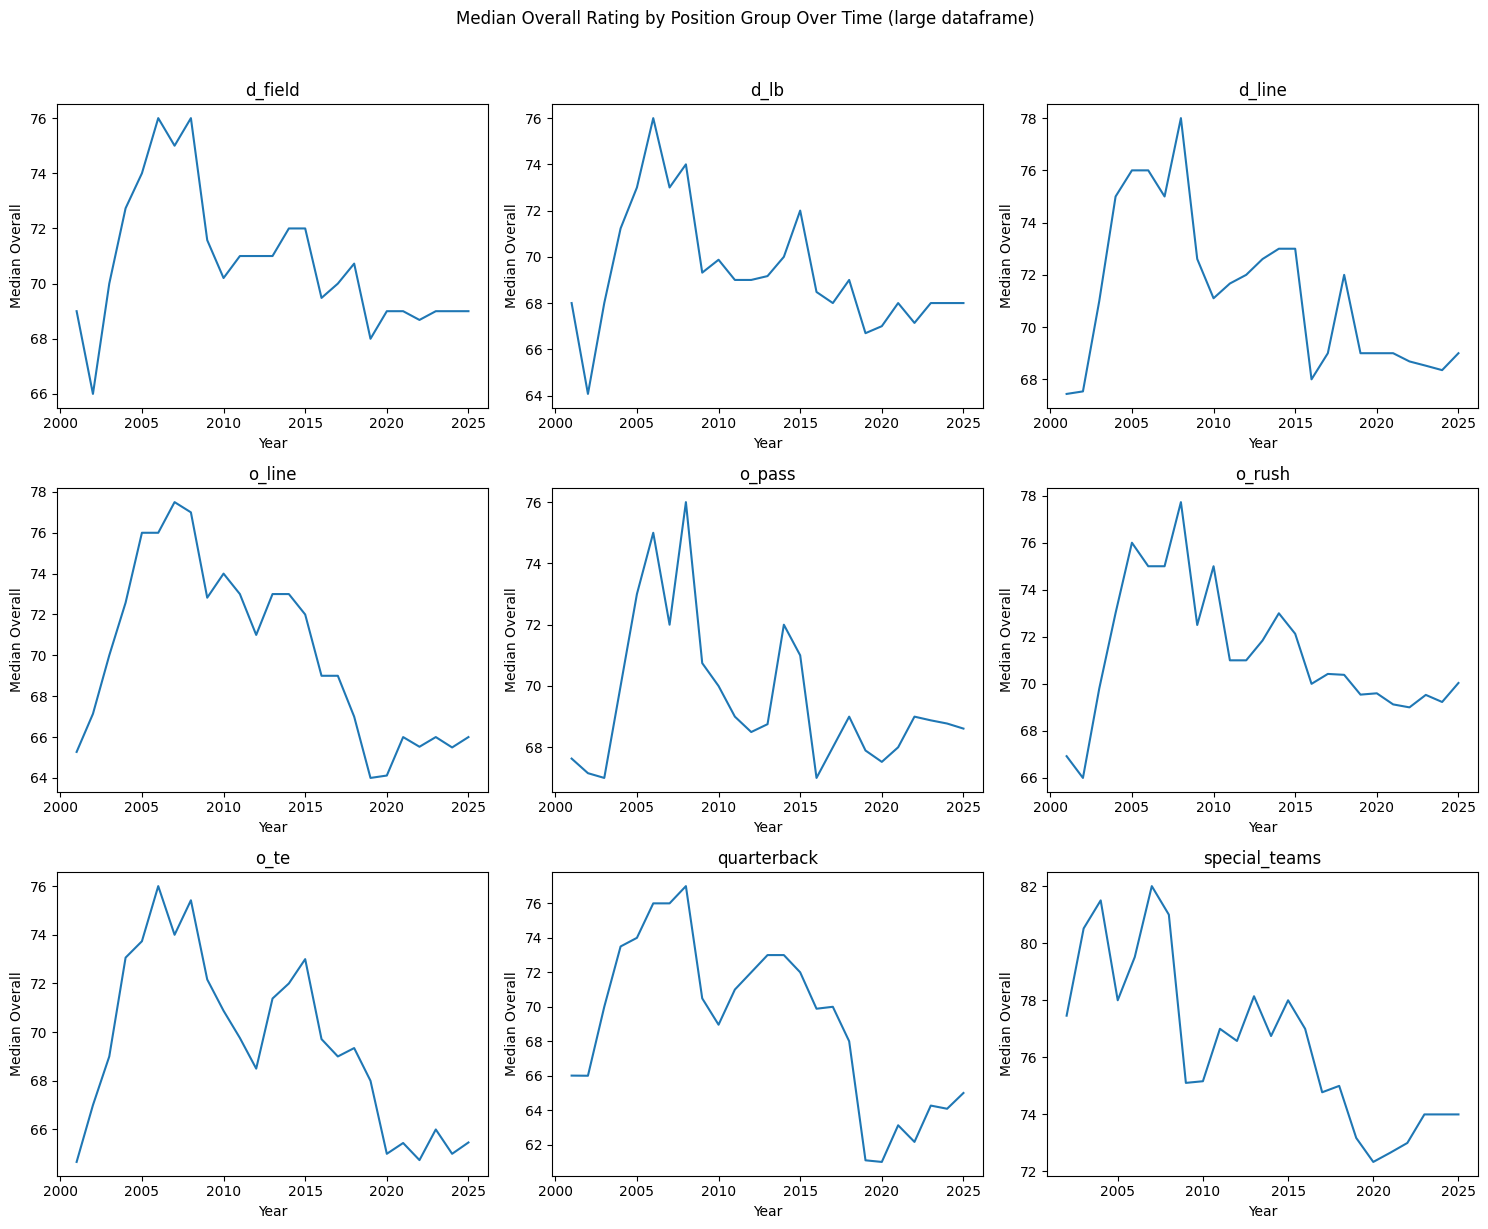

In [93]:
def plotAll(dataframe):
    groups = dataframe["position_group"].unique()
    n = len(groups)

    # Build a grid (e.g., 3 columns)
    ncols = 3
    nrows = -(-n // ncols)  # ceiling division

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4), sharey=False)
    axes = axes.flatten()  # make indexing easy

    for i, pos in enumerate(sorted(groups)):
        subset = dataframe.query("position_group == @pos")
        axes[i].plot(subset["year"], subset["median_overall"])
        axes[i].set_title(pos)
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel("Median Overall")

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Median Overall Rating by Position Group Over Time (large dataframe)", y=1.02)
    plt.tight_layout()
    plt.show()

plotAll(new_summary)

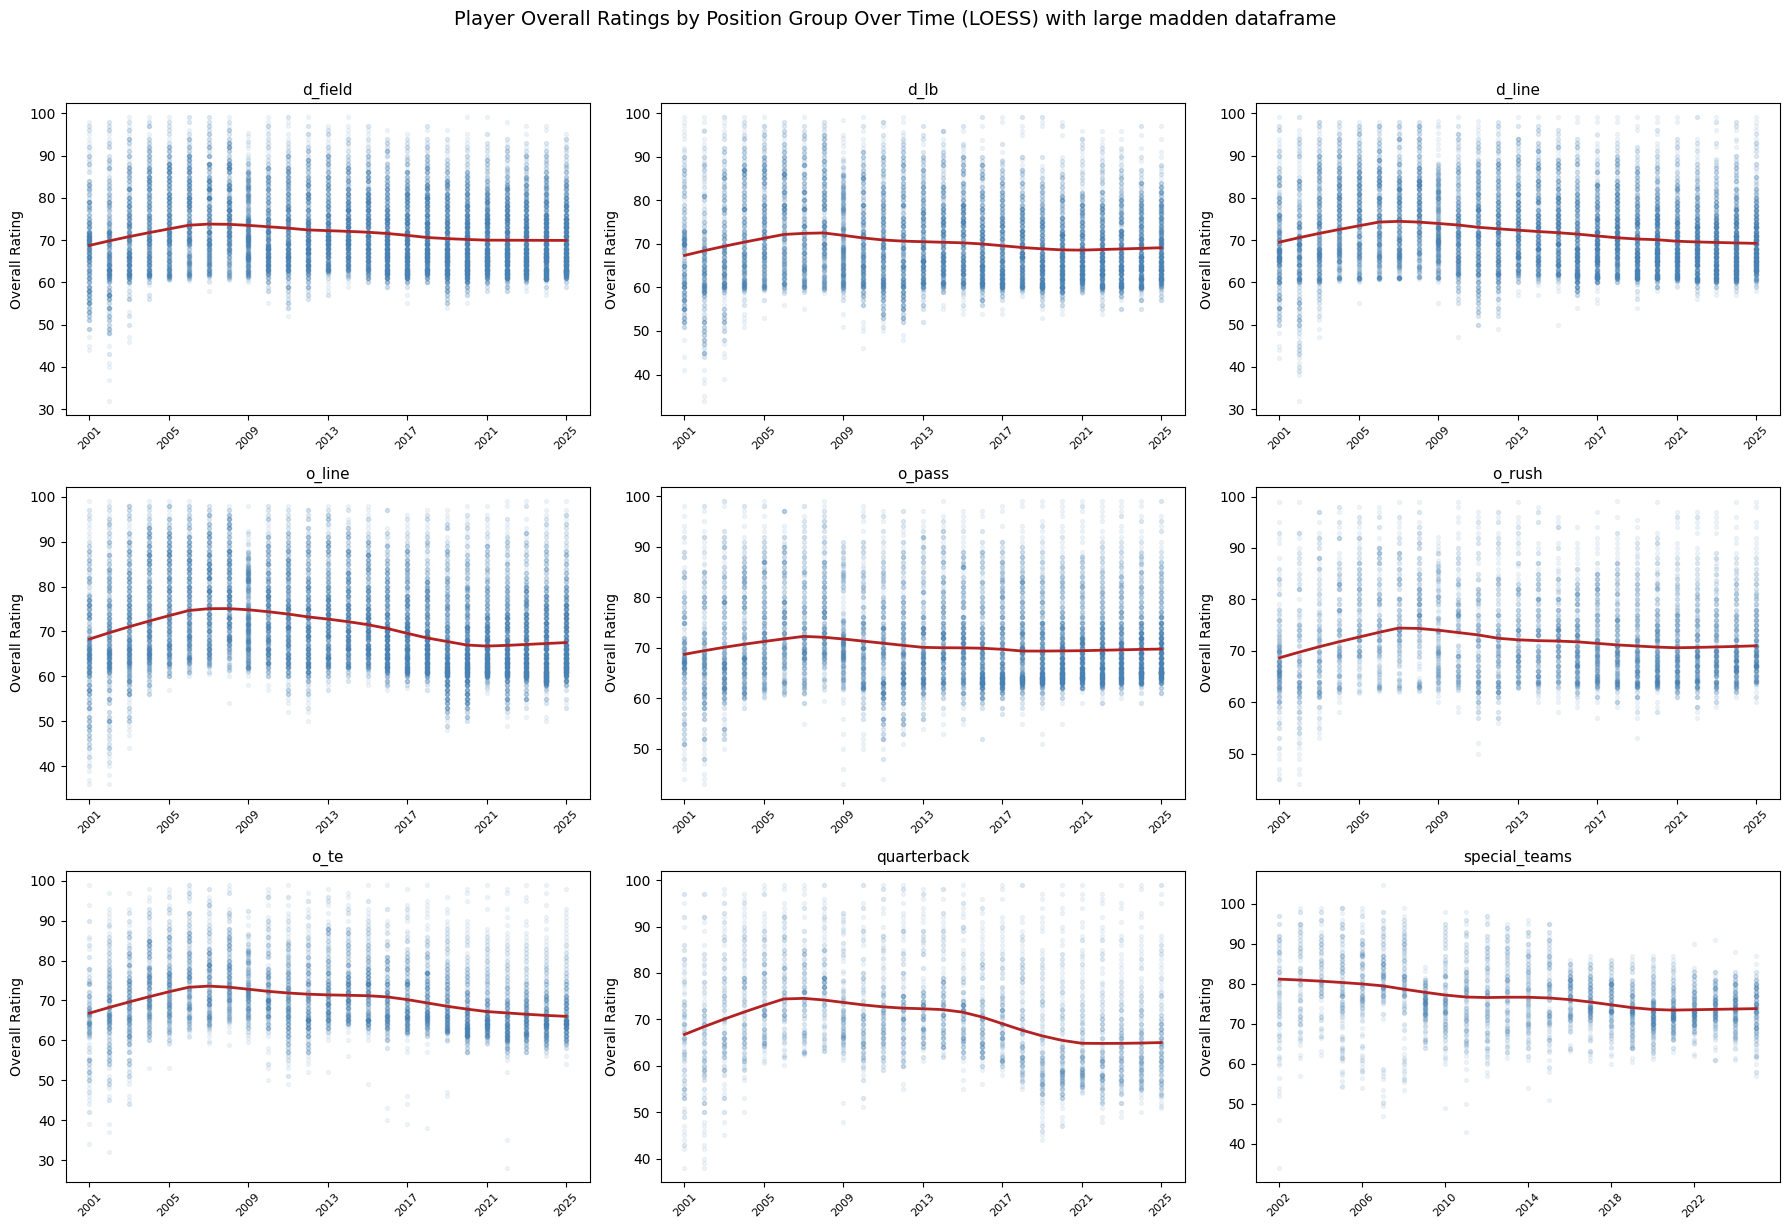

In [96]:
def plotAll(dataframe):
    groups = sorted(dataframe["position_group"].unique())
    n = len(groups)
    ncols = 3
    nrows = -(-n // ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, nrows * 4), sharey=False)
    axes = axes.flatten()

    for i, pos in enumerate(groups):
        ax = axes[i]
        subset = dataframe.query("position_group == @pos").sort_values("year")

        x = subset["year"].values
        y = subset["overallrating"].values  # individual player ratings now

        # Raw scatter — use small alpha since lots of points
        ax.scatter(x, y, alpha=0.08, s=8, color="steelblue")

        # LOESS on all individual points
        lowess = sm.nonparametric.lowess(y, x, frac=0.4)
        ax.plot(lowess[:, 0], lowess[:, 1], color="firebrick", linewidth=2)

        ax.set_title(pos, fontsize=11)
        ax.set_ylabel("Overall Rating")
        ax.set_xlabel("")

        year_min, year_max = int(x.min()), int(x.max())
        ax.set_xticks(range(year_min, year_max + 1, 4))
        ax.tick_params(axis='x', rotation=45, labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Player Overall Ratings by Position Group Over Time (LOESS) with large madden dataframe", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plotAll(madden_short)

In [97]:
new_summary

,position_group,year,mean_overall,median_overall,n,overall_sd
0,d_field,2001,68.664,69.000,353,10.289
1,d_field,2002,67.711,66.000,352,11.526
2,d_field,2003,71.794,70.000,344,10.004
3,d_field,2004,74.369,72.733,351,9.849
4,d_field,2005,75.305,74.000,365,9.394
...,...,...,...,...,...,...
219,special_teams,2021,73.408,72.659,146,4.759
220,special_teams,2022,73.720,73.000,137,4.613
221,special_teams,2023,74.169,74.000,122,4.793
222,special_teams,2024,73.903,74.000,140,4.827


In [100]:
madden_short["z_overall"] = (madden_short["overallrating"] - madden_short["median_overall"]) / madden_short["overall_sd"]
madden_short.head()

,fullname,player_id,position_group,overallrating,year,mean_overall,median_overall,n,overall_sd,z_overall
0,Shane Dronett,00-0004543,d_line,75.0,2001,69.036,67.441,321,10.346,0.730621
1,Jason Peter,00-0012842,d_line,74.0,2001,69.036,67.441,321,10.346,0.633965
2,Leonard Little,00-0009978,d_line,73.0,2001,69.036,67.441,321,10.346,0.537309
3,Junior Bryant,00-0002142,d_line,72.0,2001,69.036,67.441,321,10.346,0.440653
4,Reinard Wilson,00-0018054,d_line,69.0,2001,69.036,67.441,321,10.346,0.150686
